In [1]:
import pandas as pd
import pickle

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\HP\OneDrive - H.C. Auxilium\Desktop\Student_performance.csv")

print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [3]:
print(df.isnull().sum())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [5]:
encoder = {}

categorical_columns = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course"
]

for col in categorical_columns:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    encoder[col] = le

In [6]:
X = df[[
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course",
    "math score",
    "reading score",
    "writing score"
]]

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

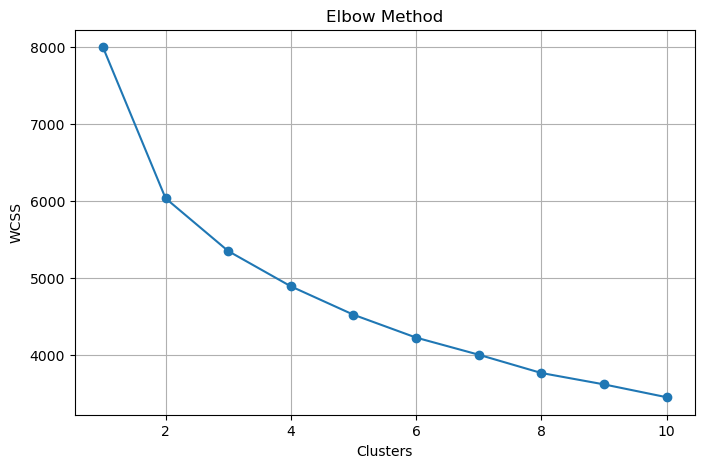

In [8]:
wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker="o")

plt.title("Elbow Method")

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.grid()

plt.show()

In [9]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

In [10]:
cluster_names = {

    0:"High Performer",

    1:"Average Performer",

    2:"Needs Improvement"

}

df["Performance"] = df["Cluster"].map(cluster_names)

In [11]:
pickle.dump(kmeans,open("kmeans_model.pkl","wb"))

pickle.dump(scaler,open("scaler.pkl","wb"))

pickle.dump(encoder,open("encoder.pkl","wb"))

In [12]:
print(df.head())

print(df["Performance"].value_counts())

   gender  race/ethnicity  parental level of education  lunch  \
0       0               1                            1      1   
1       0               2                            4      1   
2       0               1                            3      1   
3       1               0                            0      0   
4       1               2                            4      1   

   test preparation course  math score  reading score  writing score  Cluster  \
0                        1          72             72             74        0   
1                        0          69             90             88        0   
2                        1          90             95             93        0   
3                        1          47             57             44        1   
4                        1          76             78             75        2   

         Performance  
0     High Performer  
1     High Performer  
2     High Performer  
3  Average Performer  
4  Need

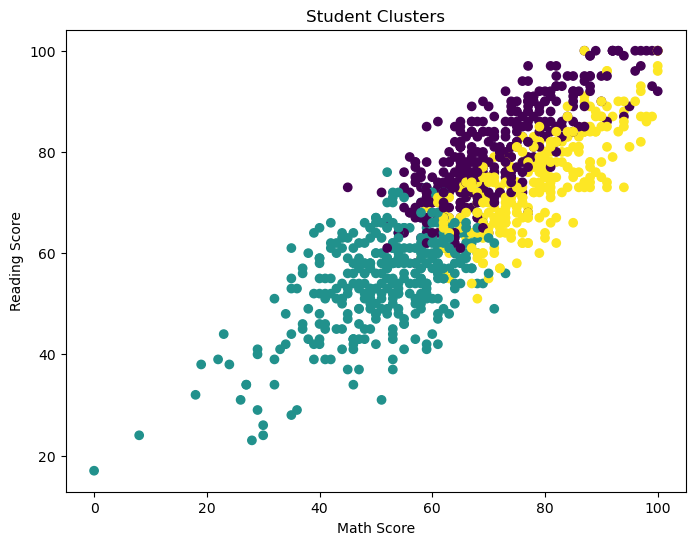

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(

    df["math score"],

    df["reading score"],

    c=df["Cluster"],

    cmap="viridis"

)

plt.xlabel("Math Score")

plt.ylabel("Reading Score")

plt.title("Student Clusters")

plt.show()

In [14]:
from tkinter import *
from tkinter import ttk
import pickle
import numpy as np

# ===========================
# Load Model
# ===========================

kmeans = pickle.load(open("kmeans_model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))
encoder = pickle.load(open("encoder.pkl", "rb"))

# ===========================
# Prediction Function
# ===========================

def predict():

    try:

        gender = gender_box.get()
        race = race_box.get()
        parent = parent_box.get()
        lunch = lunch_box.get()
        course = course_box.get()

        math = float(math_entry.get())
        reading = float(reading_entry.get())
        writing = float(writing_entry.get())

        data = [[
            encoder["gender"].transform([gender])[0],
            encoder["race/ethnicity"].transform([race])[0],
            encoder["parental level of education"].transform([parent])[0],
            encoder["lunch"].transform([lunch])[0],
            encoder["test preparation course"].transform([course])[0],
            math,
            reading,
            writing
        ]]

        data = scaler.transform(data)

        cluster = kmeans.predict(data)[0]

        if cluster == 0:
            output = "🏆 High Performer"
            color = "green"

        elif cluster == 1:
            output = "📘 Average Performer"
            color = "blue"

        else:
            output = "📕 Needs Improvement"
            color = "red"

        result.config(
            text=output,
            fg=color
        )

    except Exception as e:
        result.config(text=str(e), fg="red")


# ===========================
# GUI
# ===========================

root = Tk()

root.title("Student Performance Clustering")

root.geometry("900x750")

root.configure(bg="#0B3C5D")

heading = Label(
    root,
    text="🎓 Student Performance Clustering",
    font=("Georgia",24,"bold"),
    bg="#0B3C5D",
    fg="white"
)

heading.pack(pady=15)

sub = Label(
    root,
    text="K-Means Clustering",
    font=("Arial",13),
    bg="#0B3C5D",
    fg="white"
)

sub.pack()

frame = Frame(root,bg="white")
frame.pack(pady=20,padx=20)

# Gender

Label(frame,text="Gender",font=("Arial",12,"bold")).grid(row=0,column=0,padx=10,pady=10)

gender_box = ttk.Combobox(
    frame,
    values=["female","male"],
    state="readonly",
    width=25
)

gender_box.grid(row=0,column=1)

# Race

Label(frame,text="Race/Ethnicity",font=("Arial",12,"bold")).grid(row=1,column=0,padx=10,pady=10)

race_box = ttk.Combobox(
    frame,
    values=[
        "group A",
        "group B",
        "group C",
        "group D",
        "group E"
    ],
    state="readonly",
    width=25
)

race_box.grid(row=1,column=1)

# Parent Education

Label(frame,text="Parent Education",font=("Arial",12,"bold")).grid(row=2,column=0,padx=10,pady=10)

parent_box = ttk.Combobox(
    frame,
    values=[
        "associate's degree",
        "bachelor's degree",
        "high school",
        "master's degree",
        "some college",
        "some high school"
    ],
    state="readonly",
    width=25
)

parent_box.grid(row=2,column=1)

# Lunch

Label(frame,text="Lunch",font=("Arial",12,"bold")).grid(row=3,column=0,padx=10,pady=10)

lunch_box = ttk.Combobox(
    frame,
    values=[
        "standard",
        "free/reduced"
    ],
    state="readonly",
    width=25
)

lunch_box.grid(row=3,column=1)

# Test Preparation

Label(frame,text="Test Preparation",font=("Arial",12,"bold")).grid(row=4,column=0,padx=10,pady=10)

course_box = ttk.Combobox(
    frame,
    values=[
        "completed",
        "none"
    ],
    state="readonly",
    width=25
)

course_box.grid(row=4,column=1)

# Math

Label(frame,text="Math Score",font=("Arial",12,"bold")).grid(row=5,column=0,padx=10,pady=10)

math_entry = Entry(frame,width=28)

math_entry.grid(row=5,column=1)

# Reading

Label(frame,text="Reading Score",font=("Arial",12,"bold")).grid(row=6,column=0,padx=10,pady=10)

reading_entry = Entry(frame,width=28)

reading_entry.grid(row=6,column=1)

# Writing

Label(frame,text="Writing Score",font=("Arial",12,"bold")).grid(row=7,column=0,padx=10,pady=10)

writing_entry = Entry(frame,width=28)

writing_entry.grid(row=7,column=1)

# Button

Button(
    root,
    text="Predict Cluster",
    bg="#FF9800",
    fg="white",
    font=("Arial",14,"bold"),
    padx=20,
    pady=8,
    command=predict
).pack(pady=20)

# Result

result = Label(
    root,
    text="Cluster Result",
    bg="#0B3C5D",
    fg="yellow",
    font=("Arial",20,"bold")
)

result.pack(pady=20)

footer = Label(
    root,
    text="Developed using K-Means Clustering",
    bg="#0B3C5D",
    fg="white",
    font=("Arial",11)
)

footer.pack(side=BOTTOM,pady=10)

root.mainloop()

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
